# Directional spatial analysis of cultivation-plot DGR

## Setup

In [ ]:
options(scipen = 999)

required_packages <- c(
  "sf",
  "dplyr",
  "tidyr",
  "purrr",
  "ggplot2",
  "patchwork",
  "broom",
  "readxl",
  "stringr"
)

missing_packages <- required_packages[!vapply(
  required_packages,
  requireNamespace,
  quietly = TRUE,
  FUN.VALUE = logical(1)
)]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Missing required package(s):",
      paste(missing_packages, collapse = ", "),
      "\nInstall them before rendering this Quarto document."
    ),
    call. = FALSE
  )
}

library(sf)

Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE


Attachement du package : 'dplyr'

Les objets suivants sont masqués depuis 'package:stats':

    filter, lag

Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union

## User Parameters

In [ ]:
cadaster_path <- "Data/shp/Cadaster_NBS_Dec2025.shp"
dgr_col <- "DGR"
id_col <- "ID"

output_dir <- "Figures/Spatial_analysis"
distance_thresholds <- seq(10, 500, by = 10)
moran_distance_thresholds <- seq(50, 500, by = 50)
primary_predictor <- "mean_neighbour_DGR"
direction_levels <- c("SW", "NW", "NE", "SE")

min_model_n <- 10
global_moran_permutations <- 199
local_moran_permutations <- 199
local_moran_alpha <- 0.05

variogram_bin_width_m <- 25
variogram_max_distance_quantile <- 0.60

save_dpi <- 300
plot_width <- 8.5
plot_height <- 6.0

derive_dgr_if_missing <- TRUE
harvest_path <- "Data/NBS - Récolte 2025.xlsx"
harvest_sheet <- "Copie base donnée"
harvest_join_col <- "Module_ID"
derived_dgr_col <- "Average_DGR"

## Helper Functions

In [ ]:
save_plot <- function(plot_obj, filename, width = plot_width, height = plot_height) {
  ggplot2::ggsave(
    filename = filename,
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    dpi = save_dpi,
    bg = "white"
  )
}

theme_spatial <- function() {
  theme_minimal(base_size = 11) +
    theme(
      panel.grid.major = element_line(colour = "grey88", linewidth = 0.25),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      axis.title = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(size = 10),
      plot.caption = element_text(size = 8, colour = "grey35")
    )
}

direction_palette <- c(
  SW = "#E64B35",
  NW = "#4DBBD5",
  NE = "#00A087",
  SE = "#3C5488"
)

local_moran_palette <- c(
  "High-High" = "#B2182B",
  "Low-Low" = "#2166AC",
  "High-Low" = "#EF8A62",
  "Low-High" = "#67A9CF",
  "Non-significant" = "grey80"
)

guess_utm_epsg <- function(sf_obj) {
  centroid_wgs84 <- st_as_sfc(st_bbox(sf_obj)) |>
    st_transform(4326) |>
    st_centroid()

  centroid_xy <- st_coordinates(centroid_wgs84)
  lon <- centroid_xy[1, "X"]
  lat <- centroid_xy[1, "Y"]
  zone <- floor((lon + 180) / 6) + 1
  epsg <- if (lat >= 0) 32600 + zone else 32700 + zone
  epsg
}

derive_dgr_from_harvest <- function(
  harvest_path,
  harvest_sheet,
  derived_dgr_col = "Average_DGR"
) {
  if (!file.exists(harvest_path)) {
    stop(
      paste(
        "DGR column was not found in the shapefile and the fallback harvest file",
        "does not exist:",
        harvest_path
      ),
      call. = FALSE
    )
  }

  harvest_tbl <- readxl::read_excel(harvest_path, sheet = harvest_sheet) |>
    mutate(
      FarmID = as.numeric(FarmID),
      ModuleNumber = as.numeric(ModuleNumber),
      Harvested_Weight = as.numeric(Harvested_Weight),
      CultureDuration_days = as.numeric(CultureDuration_days),
      LinesCount = as.numeric(LinesCount)
    ) |>
    filter(
      CultureMode == "Cordes",
      !is.na(FarmID),
      !is.na(ModuleNumber),
      !is.na(Harvested_Weight),
      !is.na(CultureDuration_days),
      CultureDuration_days > 0,
      !is.na(LinesCount),
      LinesCount == 100,
      Harvested_Weight > 1000
    ) |>
    mutate(
      FarmID = stringr::str_pad(as.integer(FarmID), width = 3, pad = "0"),
      ModuleNumber = as.integer(ModuleNumber),
      Module_ID = paste0(FarmID, "_", ModuleNumber),
      DGR = (log(Harvested_Weight / 700) / CultureDuration_days) * 100
    ) |>
    group_by(Module_ID) |>
    summarise(
      Average_DGR = mean(DGR, na.rm = TRUE),
      .groups = "drop"
    )

  names(harvest_tbl)[names(harvest_tbl) == "Average_DGR"] <- derived_dgr_col
  harvest_tbl
}

prepare_cadaster <- function(
  cadaster_path,
  dgr_col,
  id_col,
  derive_dgr_if_missing = FALSE,
  harvest_path = NULL,
  harvest_sheet = NULL,
  harvest_join_col = "Module_ID",
  derived_dgr_col = "Average_DGR"
) {
  if (!file.exists(cadaster_path)) {
    stop(paste("Cadaster shapefile not found:", cadaster_path), call. = FALSE)
  }

  cadaster_sf <- st_read(cadaster_path, quiet = TRUE)
  cadaster_sf <- st_make_valid(cadaster_sf)

  if (!id_col %in% names(cadaster_sf)) {
    stop(
      paste(
        "The plot identifier column was not found in the shapefile:",
        id_col
      ),
      call. = FALSE
    )
  }

  original_crs <- st_crs(cadaster_sf)
  if (is.na(original_crs)) {
    stop("The input shapefile has no CRS defined.", call. = FALSE)
  }

  original_crs_label <- original_crs$input
  transformed_crs_label <- original_crs_label

  if (isTRUE(st_is_longlat(cadaster_sf))) {
    utm_epsg <- guess_utm_epsg(cadaster_sf)
    cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
    transformed_crs_label <- paste0("EPSG:", utm_epsg)
  } else {
    crs_units_raw <- original_crs$units_gdal
    crs_units <- if (is.null(crs_units_raw) || length(crs_units_raw) == 0 || is.na(crs_units_raw)) {
      ""
    } else {
      tolower(crs_units_raw)
    }
    if (!crs_units %in% c("metre", "meter", "m")) {
      utm_epsg <- guess_utm_epsg(cadaster_sf)
      cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
      transformed_crs_label <- paste0("EPSG:", utm_epsg)
    }
  }

  working_dgr_col <- dgr_col
  dgr_source <- "shapefile"

  if (!dgr_col %in% names(cadaster_sf)) {
    if (!derive_dgr_if_missing) {
      stop(
        paste(
          "The requested DGR column was not found in the shapefile:",
          dgr_col
        ),
        call. = FALSE
      )
    }

    derived_dgr_tbl <- derive_dgr_from_harvest(
      harvest_path = harvest_path,
      harvest_sheet = harvest_sheet,
      derived_dgr_col = derived_dgr_col
    )

    cadaster_sf <- cadaster_sf |>
      left_join(
        derived_dgr_tbl,
        by = setNames(harvest_join_col, id_col)
      )

    working_dgr_col <- derived_dgr_col
    dgr_source <- "derived_from_harvest_workbook"
  }

  cadaster_sf <- cadaster_sf |>
    mutate(
      plot_id = as.character(.data[[id_col]]),
      DGR = suppressWarnings(as.numeric(.data[[working_dgr_col]]))
    )

  if (anyDuplicated(cadaster_sf$plot_id) > 0) {
    stop(
      "The selected plot identifier column is not unique after preparation.",
      call. = FALSE
    )
  }

  dropped_missing_dgr <- sum(is.na(cadaster_sf$DGR))
  cadaster_sf <- cadaster_sf |>
    filter(!is.na(DGR))

  if (nrow(cadaster_sf) < 5) {
    stop(
      "Too few plots remain after removing missing DGR values.",
      call. = FALSE
    )
  }

  centroid_points <- st_point_on_surface(cadaster_sf)
  centroid_coords <- st_coordinates(centroid_points)

  cadaster_sf <- cadaster_sf |>
    mutate(
      x = centroid_coords[, "X"],
      y = centroid_coords[, "Y"]
    )

  list(
    data = cadaster_sf,
    metadata = list(
      original_crs = original_crs_label,
      analysis_crs = transformed_crs_label,
      dgr_source = dgr_source,
      working_dgr_col = working_dgr_col,
      dropped_missing_dgr = dropped_missing_dgr
    )
  )
}

classify_direction <- function(dx, dy) {
  dplyr::case_when(
    dx > 0 & dy > 0 ~ "NE",
    dx < 0 & dy > 0 ~ "NW",
    dx < 0 & dy < 0 ~ "SW",
    dx > 0 & dy < 0 ~ "SE",
    TRUE ~ NA_character_
  )
}

inverse_distance_weighted_mean <- function(values, distances) {
  keep <- !is.na(values) & !is.na(distances) & distances > 0
  if (!any(keep)) {
    return(NA_real_)
  }
  stats::weighted.mean(values[keep], w = 1 / distances[keep])
}

build_pairwise_table <- function(plot_sf, direction_levels) {
  plot_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, DGR, x, y)

  pairwise_all <- tidyr::expand_grid(
    focal_index = seq_len(nrow(plot_tbl)),
    neighbour_index = seq_len(nrow(plot_tbl))
  ) |>
    filter(focal_index != neighbour_index) |>
    transmute(
      focal_index = focal_index,
      neighbour_index = neighbour_index,
      plot_id = plot_tbl$plot_id[focal_index],
      neighbour_id = plot_tbl$plot_id[neighbour_index],
      focal_DGR = plot_tbl$DGR[focal_index],
      neighbour_DGR = plot_tbl$DGR[neighbour_index],
      dx = plot_tbl$x[neighbour_index] - plot_tbl$x[focal_index],
      dy = plot_tbl$y[neighbour_index] - plot_tbl$y[focal_index]
    ) |>
    mutate(
      distance_m = sqrt(dx^2 + dy^2),
      bearing_deg = (atan2(dy, dx) * 180 / pi + 360) %% 360,
      direction = classify_direction(dx, dy)
    )

  pairwise_directional <- pairwise_all |>
    filter(!is.na(direction)) |>
    mutate(direction = factor(direction, levels = direction_levels))

  list(
    pairwise_all = pairwise_all,
    pairwise_directional = pairwise_directional
  )
}

compute_directional_metrics <- function(
  pairwise_directional,
  plot_sf,
  distance_thresholds,
  direction_levels
) {
  focal_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, DGR)

  base_grid <- tidyr::expand_grid(
    plot_id = focal_tbl$plot_id,
    direction = factor(direction_levels, levels = direction_levels)
  )

  metrics_tbl <- purrr::map_dfr(distance_thresholds, function(threshold_m) {
    threshold_summary <- pairwise_directional |>
      filter(distance_m <= threshold_m) |>
      group_by(plot_id, direction) |>
      summarise(
        n_neighbours = dplyr::n(),
        mean_neighbour_DGR = mean(neighbour_DGR, na.rm = TRUE),
        median_neighbour_DGR = median(neighbour_DGR, na.rm = TRUE),
        min_distance_m = min(distance_m, na.rm = TRUE),
        idw_neighbour_DGR = inverse_distance_weighted_mean(
          neighbour_DGR,
          distance_m
        ),
        .groups = "drop"
      )

    base_grid |>
      left_join(threshold_summary, by = c("plot_id", "direction")) |>
      mutate(
        distance_threshold_m = threshold_m,
        n_neighbours = tidyr::replace_na(n_neighbours, 0L)
      ) |>
      left_join(focal_tbl, by = "plot_id") |>
      mutate(
        DGR_difference = DGR - mean_neighbour_DGR
      )
  })

  metrics_tbl
}

safe_lm_summary <- function(data, predictor, response = "DGR", min_n = 10) {
  model_data <- data |>
    select(all_of(c(response, predictor))) |>
    tidyr::drop_na()

  if (nrow(model_data) < min_n) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      relationship_sign = NA_character_,
      status = paste0("Skipped: sample size < ", min_n)
    ))
  }

  if (dplyr::n_distinct(model_data[[predictor]]) < 2) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      relationship_sign = NA_character_,
      status = "Skipped: predictor has insufficient variation"
    ))
  }

  fit <- tryCatch(
    stats::lm(stats::as.formula(paste(response, "~", predictor)), data = model_data),
    error = function(e) e
  )

  if (inherits(fit, "error")) {
    return(tibble(
      predictor = predictor,
      slope = NA_real_,
      p_value = NA_real_,
      r_squared = NA_real_,
      adj_r_squared = NA_real_,
      AIC = NA_real_,
      sample_size = nrow(model_data),
      conf_low = NA_real_,
      conf_high = NA_real_,
      relationship_sign = NA_character_,
      status = paste("Skipped:", fit$message)
    ))
  }

  fit_tidy <- broom::tidy(fit, conf.int = TRUE)
  fit_glance <- broom::glance(fit)
  slope_row <- fit_tidy |>
    filter(term == predictor)

  tibble(
    predictor = predictor,
    slope = slope_row$estimate[1],
    p_value = slope_row$p.value[1],
    r_squared = fit_glance$r.squared[1],
    adj_r_squared = fit_glance$adj.r.squared[1],
    AIC = stats::AIC(fit),
    sample_size = stats::nobs(fit),
    conf_low = slope_row$conf.low[1],
    conf_high = slope_row$conf.high[1],
    relationship_sign = dplyr::case_when(
      slope_row$estimate[1] > 0 ~ "positive",
      slope_row$estimate[1] < 0 ~ "negative",
      TRUE ~ "neutral"
    ),
    status = "OK"
  )
}

fit_directional_models <- function(
  metrics_tbl,
  predictors,
  min_model_n = 10
) {
  split_tbl <- split(
    metrics_tbl,
    list(metrics_tbl$direction, metrics_tbl$distance_threshold_m),
    drop = TRUE
  )

  purrr::map_dfr(split_tbl, function(group_df) {
    group_direction <- as.character(unique(group_df$direction))
    group_threshold <- unique(group_df$distance_threshold_m)

    purrr::map_dfr(
      predictors,
      ~ safe_lm_summary(group_df, predictor = .x, min_n = min_model_n)
    ) |>
      mutate(
        direction = group_direction,
        distance_threshold_m = group_threshold
      ) |>
      relocate(direction, distance_threshold_m, predictor)
  })
}

make_distance_plot <- function(model_results, y_var, y_label, file_path, add_p_line = FALSE) {
  plot_obj <- model_results |>
    filter(predictor == primary_predictor) |>
    ggplot(aes(x = distance_threshold_m, y = .data[[y_var]], colour = direction)) +
    geom_line(linewidth = 0.8, na.rm = TRUE) +
    geom_point(size = 1.8, na.rm = TRUE) +
    scale_colour_manual(values = direction_palette, drop = FALSE) +
    labs(
      x = "Distance threshold (m)",
      y = y_label,
      colour = "Direction"
    ) +
    theme_spatial()

  if (add_p_line) {
    plot_obj <- plot_obj +
      geom_hline(yintercept = 0.05, linetype = "dashed", colour = "grey35")
  }

  save_plot(plot_obj, file_path)
  plot_obj
}

build_distance_weights <- function(dist_matrix, threshold_m) {
  neighbours <- lapply(
    seq_len(nrow(dist_matrix)),
    function(i) which(dist_matrix[i, ] > 0 & dist_matrix[i, ] <= threshold_m)
  )

  weights <- lapply(
    neighbours,
    function(idx) {
      if (length(idx) == 0) {
        numeric(0)
      } else {
        rep(1 / length(idx), length(idx))
      }
    }
  )

  list(neighbours = neighbours, weights = weights)
}

build_adjacency_weights <- function(plot_sf) {
  neighbours <- st_touches(plot_sf)
  weights <- lapply(
    neighbours,
    function(idx) {
      if (length(idx) == 0) {
        numeric(0)
      } else {
        rep(1 / length(idx), length(idx))
      }
    }
  )

  list(neighbours = neighbours, weights = weights)
}

spatial_lag_from_weights <- function(values, neighbours, weights) {
  vapply(
    seq_along(neighbours),
    function(i) {
      if (length(neighbours[[i]]) == 0) {
        0
      } else {
        sum(weights[[i]] * values[neighbours[[i]]])
      }
    },
    numeric(1)
  )
}

compute_global_moran <- function(values, neighbours, weights, n_perm = 199) {
  centered <- values - mean(values)
  denom <- sum(centered^2)
  s0 <- sum(vapply(weights, sum, numeric(1)))

  if (denom == 0 || s0 == 0) {
    return(tibble(
      moran_i = NA_real_,
      expected_i = NA_real_,
      p_value = NA_real_,
      n_permutations = n_perm,
      mean_neighbours = mean(lengths(neighbours)),
      min_neighbours = min(lengths(neighbours)),
      max_neighbours = max(lengths(neighbours)),
      n_isolates = sum(lengths(neighbours) == 0)
    ))
  }

  n <- length(values)
  observed_lag <- spatial_lag_from_weights(centered, neighbours, weights)
  observed_i <- (n / s0) * sum(centered * observed_lag) / denom

  permuted_i <- vapply(
    seq_len(n_perm),
    function(.x) {
      permuted <- sample(centered)
      permuted_lag <- spatial_lag_from_weights(permuted, neighbours, weights)
      (n / s0) * sum(permuted * permuted_lag) / sum(permuted^2)
    },
    numeric(1)
  )

  tibble(
    moran_i = observed_i,
    expected_i = -1 / (n - 1),
    p_value = (sum(abs(permuted_i) >= abs(observed_i)) + 1) / (n_perm + 1),
    n_permutations = n_perm,
    mean_neighbours = mean(lengths(neighbours)),
    min_neighbours = min(lengths(neighbours)),
    max_neighbours = max(lengths(neighbours)),
    n_isolates = sum(lengths(neighbours) == 0)
  )
}

compute_local_moran <- function(
  values,
  neighbours,
  weights,
  n_perm = 199,
  alpha = 0.05
) {
  z_scores <- as.numeric(scale(values, center = TRUE, scale = TRUE))
  z_scores[is.na(z_scores)] <- 0

  lag_z <- spatial_lag_from_weights(z_scores, neighbours, weights)
  observed_i <- z_scores * lag_z

  permuted_stats <- replicate(n_perm, {
    permuted <- sample(z_scores)
    permuted * spatial_lag_from_weights(permuted, neighbours, weights)
  })

  p_values <- vapply(
    seq_along(observed_i),
    function(i) {
      (sum(abs(permuted_stats[i, ]) >= abs(observed_i[i])) + 1) / (n_perm + 1)
    },
    numeric(1)
  )

  cluster <- case_when(
    lengths(neighbours) == 0 ~ "Non-significant",
    p_values > alpha ~ "Non-significant",
    z_scores > 0 & lag_z > 0 ~ "High-High",
    z_scores < 0 & lag_z < 0 ~ "Low-Low",
    z_scores > 0 & lag_z < 0 ~ "High-Low",
    z_scores < 0 & lag_z > 0 ~ "Low-High",
    TRUE ~ "Non-significant"
  )

  tibble(
    local_moran_i = observed_i,
    local_p_value = p_values,
    z_score = z_scores,
    lag_z = lag_z,
    cluster = factor(
      cluster,
      levels = c("High-High", "Low-Low", "High-Low", "Low-High", "Non-significant")
    )
  )
}

select_local_moran_definition <- function(moran_results) {
  significant_distance <- moran_results |>
    filter(
      method == "distance",
      !is.na(moran_i),
      p_value < local_moran_alpha
    ) |>
    arrange(p_value, desc(moran_i), distance_threshold_m)

  significant_adjacency <- moran_results |>
    filter(
      method == "adjacency",
      !is.na(moran_i),
      p_value < local_moran_alpha
    ) |>
    arrange(p_value, desc(moran_i))

  if (nrow(significant_distance) > 0) {
    return(significant_distance[1, ])
  }

  if (nrow(significant_adjacency) > 0) {
    return(significant_adjacency[1, ])
  }

  moran_results |>
    filter(!is.na(moran_i)) |>
    arrange(desc(moran_i), p_value) |>
    slice(1)
}

build_empirical_variogram <- function(
  pairwise_all,
  max_distance_quantile = 0.60,
  bin_width_m = 25
) {
  variogram_pairs <- pairwise_all |>
    filter(focal_index < neighbour_index)

  max_distance_m <- stats::quantile(
    variogram_pairs$distance_m,
    probs = max_distance_quantile,
    na.rm = TRUE
  )

  empirical_tbl <- variogram_pairs |>
    filter(distance_m <= max_distance_m) |>
    transmute(
      distance_m = distance_m,
      semivariance = 0.5 * (focal_DGR - neighbour_DGR)^2,
      distance_bin = cut(
        distance_m,
        breaks = seq(0, max_distance_m + bin_width_m, by = bin_width_m),
        include.lowest = TRUE,
        right = FALSE
      )
    ) |>
    group_by(distance_bin) |>
    summarise(
      mean_distance_m = mean(distance_m, na.rm = TRUE),
      gamma = mean(semivariance, na.rm = TRUE),
      n_pairs = dplyr::n(),
      .groups = "drop"
    ) |>
    filter(is.finite(mean_distance_m), is.finite(gamma))

  list(
    empirical = empirical_tbl,
    max_distance_m = max_distance_m
  )
}

fit_simple_variogram_model <- function(empirical_tbl) {
  if (nrow(empirical_tbl) < 4) {
    return(NULL)
  }

  start_nugget <- max(min(empirical_tbl$gamma, na.rm = TRUE), 0)
  start_sill <- max(max(empirical_tbl$gamma, na.rm = TRUE) - start_nugget, 0.001)
  start_range <- max(stats::median(empirical_tbl$mean_distance_m, na.rm = TRUE), 1)

  tryCatch(
    stats::nls(
      gamma ~ nugget + sill * (1 - exp(-mean_distance_m / range)),
      data = empirical_tbl,
      start = list(
        nugget = start_nugget,
        sill = start_sill,
        range = start_range
      ),
      algorithm = "port",
      lower = c(0, 0, 1)
    ),
    error = function(e) NULL
  )
}

write_interpretation <- function(
  output_file,
  metadata,
  best_summary,
  moran_results,
  local_cluster_counts,
  strongest_direction_row,
  local_moran_definition,
  variogram_fit
) {
  significant_moran <- moran_results |>
    filter(!is.na(p_value), p_value < local_moran_alpha) |>
    arrange(p_value, desc(moran_i))

  spatial_structure_text <- if (nrow(significant_moran) > 0) {
    top_row <- significant_moran[1, ]
    definition_text <- if (top_row$method[1] == "distance") {
      paste0(top_row$distance_threshold_m[1], " m distance neighbours")
    } else {
      "polygon adjacency neighbours"
    }

    sprintf(
      paste(
        "DGR appears spatially structured in this exploratory analysis.",
        "The strongest global Moran's I signal was observed for %s",
        "(I = %.3f, p = %.3f)."
      ),
      definition_text,
      top_row$moran_i[1],
      top_row$p_value[1]
    )
  } else {
    paste(
      "Global Moran's I did not show a clearly significant positive spatial",
      "autocorrelation signal under the tested neighbour definitions, so",
      "evidence for broad-scale spatial structure is limited."
    )
  }

  strongest_direction_text <- if (nrow(strongest_direction_row) == 1) {
    sprintf(
      paste(
        "The strongest directional relationship for the primary model",
        "(DGR ~ %s) occurred in the %s sector at %d m",
        "(R² = %.3f, slope = %.3f, p = %.3f), indicating a %s association."
      ),
      primary_predictor,
      strongest_direction_row$direction[1],
      strongest_direction_row$best_r2_threshold_m[1],
      strongest_direction_row$best_r2[1],
      strongest_direction_row$best_r2_slope[1],
      strongest_direction_row$best_r2_p_value[1],
      strongest_direction_row$relationship_sign[1]
    )
  } else {
    paste(
      "No directional relationship met the minimum modelling requirements",
      "for the selected primary predictor."
    )
  }

  threshold_text <- if (nrow(strongest_direction_row) == 1) {
    sprintf(
      paste(
        "The most relevant tested distance threshold was %d m for the strongest",
        "directional signal."
      ),
      strongest_direction_row$best_r2_threshold_m[1]
    )
  } else {
    "No single distance threshold stands out from the tested set."
  }

  local_cluster_text <- if (nrow(local_cluster_counts) > 0) {
    paste(
      apply(local_cluster_counts, 1, function(row) {
        sprintf("%s: %s", row[["cluster"]], row[["n"]])
      }),
      collapse = "; "
    )
  } else {
    "No Local Moran cluster counts were available."
  }

  variogram_text <- if (!is.null(variogram_fit)) {
    fit_coef <- stats::coef(variogram_fit)
    sprintf(
      paste(
        "A simple exponential variogram model was fitted successfully.",
        "Its nominal range parameter was %.1f m, corresponding to an",
        "approximate practical range of %.1f m."
      ),
      fit_coef[["range"]],
      3 * fit_coef[["range"]]
    )
  } else {
    paste(
      "A simple variogram model could not be fitted robustly, so the",
      "variogram should be interpreted descriptively."
    )
  }

  interpretation_lines <- c(
    "# Spatial analysis interpretation",
    "",
    "## Data context",
    sprintf("- Input shapefile: `%s`", cadaster_path),
    sprintf("- DGR source used in the analysis: `%s`", metadata$dgr_source),
    sprintf("- Original CRS: `%s`", metadata$original_crs),
    sprintf("- Analysis CRS: `%s`", metadata$analysis_crs),
    sprintf("- Plots removed because of missing DGR: `%d`", metadata$dropped_missing_dgr),
    "",
    "## Main findings",
    paste0("- ", spatial_structure_text),
    paste0("- ", strongest_direction_text),
    paste0("- ", threshold_text),
    paste0("- Local Moran cluster counts for the selected neighbour definition: ", local_cluster_text, "."),
    paste0(
      "- Local Moran map used the neighbour definition: `",
      local_moran_definition$method[1],
      if (local_moran_definition$method[1] == "distance") {
        paste0(" (", local_moran_definition$distance_threshold_m[1], " m)")
      } else {
        ""
      },
      "`."
    ),
    paste0("- ", variogram_text),
    "",
    "## Statistical cautions",
    "- These results are exploratory because neighbouring plots are not fully independent observations.",
    "- Correlation and spatial clustering do not imply causation.",
    "- Directional relationships should be judged using effect size, R², AIC, and consistency across thresholds, not p-values alone.",
    "",
    "## Recommendations",
    "- Extend this workflow with environmental covariates such as depth, current exposure, hydrodynamic setting, or distance to the reef crest.",
    "- Consider spatial regression or mixed-effects models if inference, rather than exploration, becomes the main objective.",
    "- Inspect whether plot geometry, farm identity, or management regime explain part of the observed spatial structure."
  )

  writeLines(interpretation_lines, con = output_file)
}

## Load And Prepare The Cadaster

In [ ]:
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

prep <- prepare_cadaster(
  cadaster_path = cadaster_path,
  dgr_col = dgr_col,
  id_col = id_col,
  derive_dgr_if_missing = derive_dgr_if_missing,
  harvest_path = harvest_path,
  harvest_sheet = harvest_sheet,
  harvest_join_col = harvest_join_col,
  derived_dgr_col = derived_dgr_col
)

Original CRS: WGS 84 / UTM zone 39S 

Analysis CRS: WGS 84 / UTM zone 39S 

DGR source: derived_from_harvest_workbook 

Plots used: 683 

Plots removed because of missing DGR: 30 

## Map Of DGR

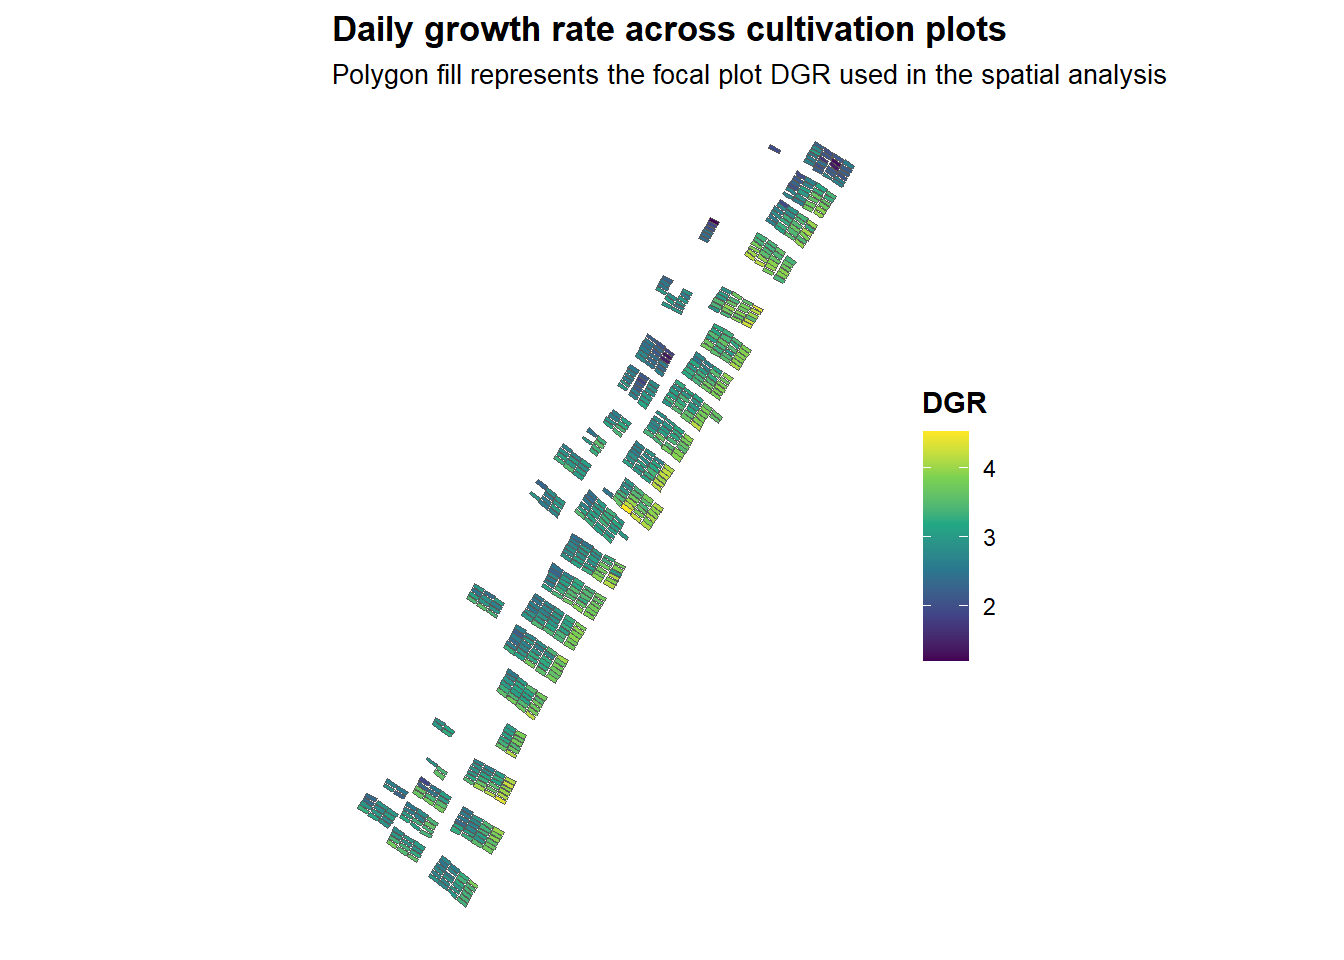

In [ ]:
dgr_map <- ggplot(plot_sf) +
  geom_sf(aes(fill = DGR), colour = "grey35", linewidth = 0.08) +
  scale_fill_viridis_c(
    option = "D",
    name = "DGR"
  ) +
  labs(
    title = "Daily growth rate across cultivation plots",
    subtitle = "Polygon fill represents the focal plot DGR used in the spatial analysis",
    x = NULL,
    y = NULL
  ) +
  coord_sf(datum = NA) +
  theme_spatial()

save_plot(
  dgr_map,
  file.path(output_dir, "dgr_map.png"),
  width = 8.5,
  height = 6.5
)

dgr_map

## Directional Neighbour Metrics

In [ ]:
pairwise_objects <- build_pairwise_table(plot_sf, direction_levels = direction_levels)
pairwise_all <- pairwise_objects$pairwise_all
pairwise_directional <- pairwise_objects$pairwise_directional

axis_aligned_pairs_removed <- nrow(pairwise_all) - nrow(pairwise_directional)
cat("Directed plot pairs retained:", nrow(pairwise_directional), "\n")

Directed plot pairs retained: 465806 

Axis-aligned pairs excluded from directional sectors: 0 

ℹ In argument: `min_distance_m = min(distance_m, na.rm = TRUE)`.
Caused by warning in `min()`:
! aucun argument trouvé pour min ; Inf est renvoyé

# A tibble: 6 × 10
  ID    direction n_neighbours mean_neighbour_DGR median_neighbour_DGR
  <chr> <fct>            <int>              <dbl>                <dbl>
1 001_1 SW                   0              NA                   NA   
2 001_1 SW                   1               3.61                 3.61
3 001_1 SW                   1               3.61                 3.61
4 001_1 SW                   1               3.61                 3.61
5 001_1 SW                   1               3.61                 3.61
6 001_1 SW                   1               3.61                 3.61
# ℹ 5 more variables: min_distance_m <dbl>, idw_neighbour_DGR <dbl>,
#   distance_threshold_m <dbl>, DGR <dbl>, DGR_difference <dbl>

## Directional Model Fitting

In [ ]:
model_predictors <- c("mean_neighbour_DGR", "idw_neighbour_DGR", "n_neighbours")

model_results <- fit_directional_models(
  metrics_tbl = metrics_tbl,
  predictors = model_predictors,
  min_model_n = min_model_n
) |>
  arrange(direction, predictor, distance_threshold_m)

utils::write.csv(
  model_results,
  file.path(output_dir, "directional_model_results.csv"),
  row.names = FALSE
)

head(model_results)

# A tibble: 6 × 13
  direction distance_threshold_m predictor          slope    p_value r_squared
  <chr>                    <dbl> <chr>              <dbl>      <dbl>     <dbl>
1 NE                          10 idw_neighbour_DGR NA     NA            NA    
2 NE                          20 idw_neighbour_DGR  0.855  4.32e-171     0.761
3 NE                          30 idw_neighbour_DGR  0.858  6.14e-174     0.764
4 NE                          40 idw_neighbour_DGR  0.870  1.21e-174     0.763
5 NE                          50 idw_neighbour_DGR  0.837  2.01e-162     0.725
6 NE                          60 idw_neighbour_DGR  0.808  1.15e-146     0.664
# ℹ 7 more variables: adj_r_squared <dbl>, AIC <dbl>, sample_size <int>,
#   conf_low <dbl>, conf_high <dbl>, relationship_sign <chr>, status <chr>

## Distance-Threshold Analysis

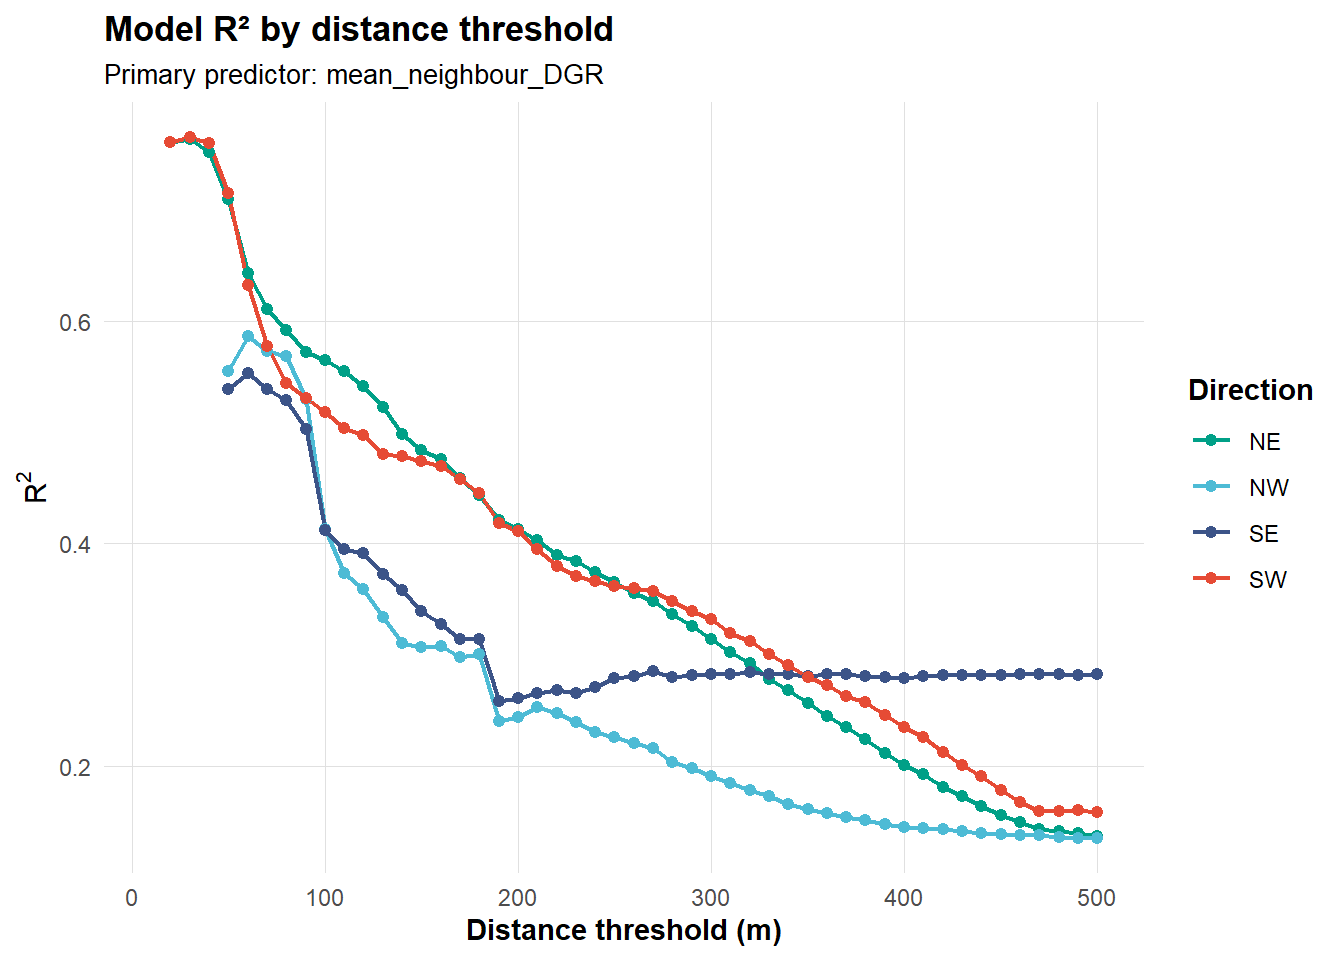

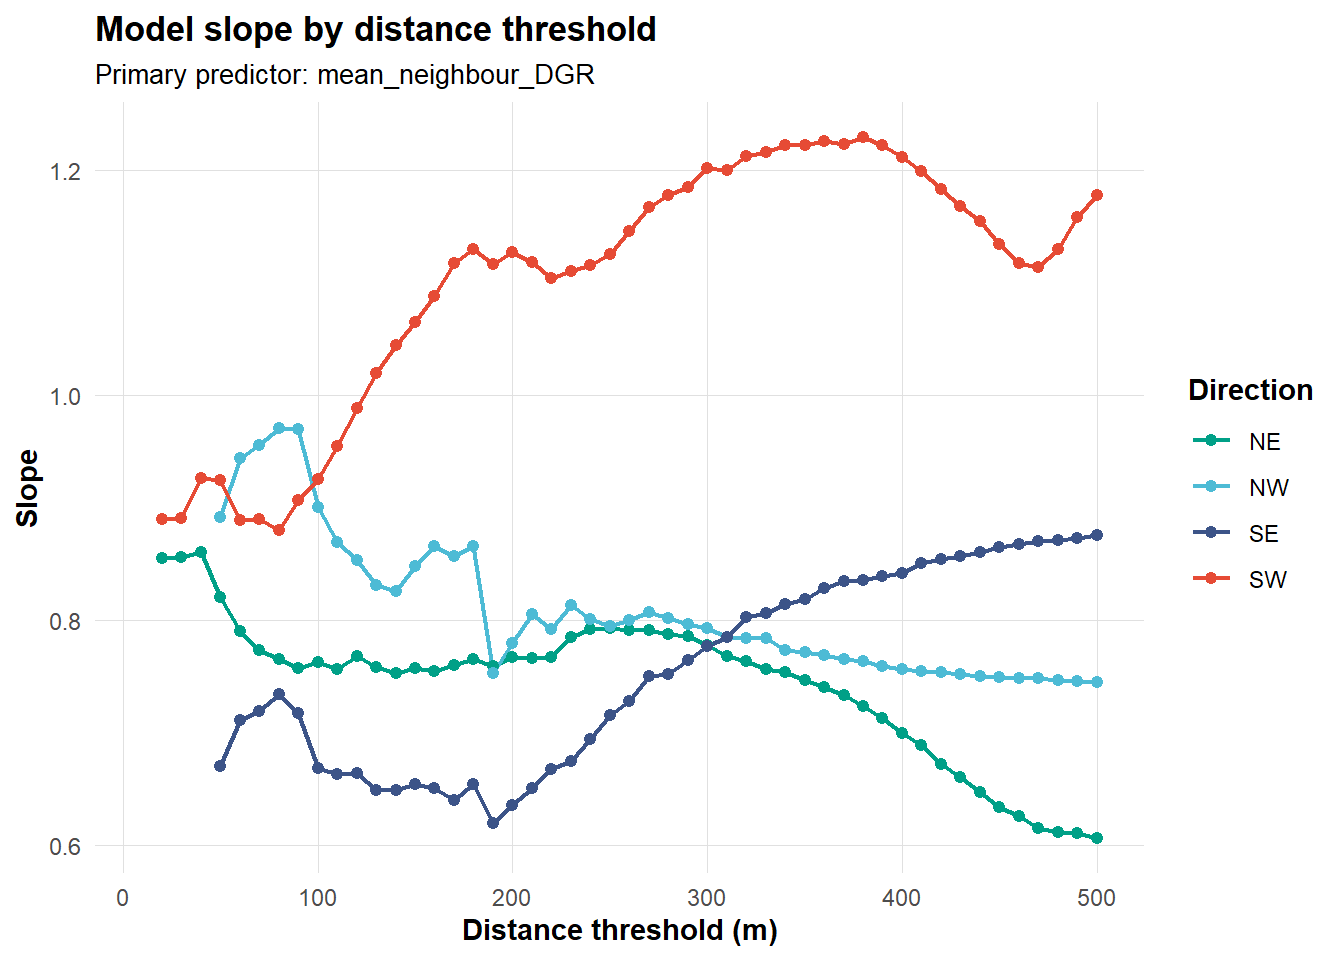

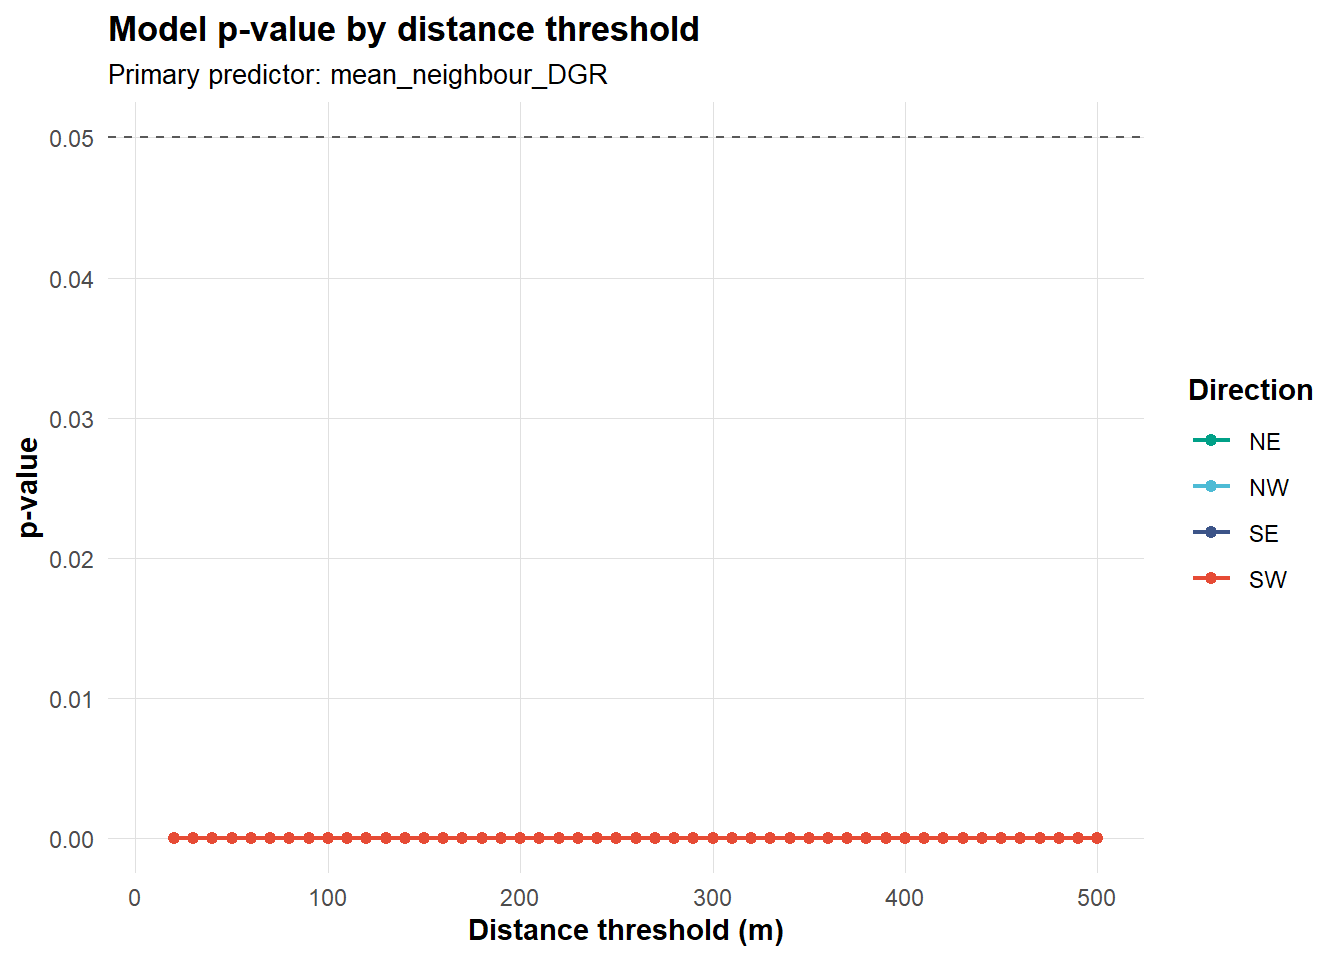

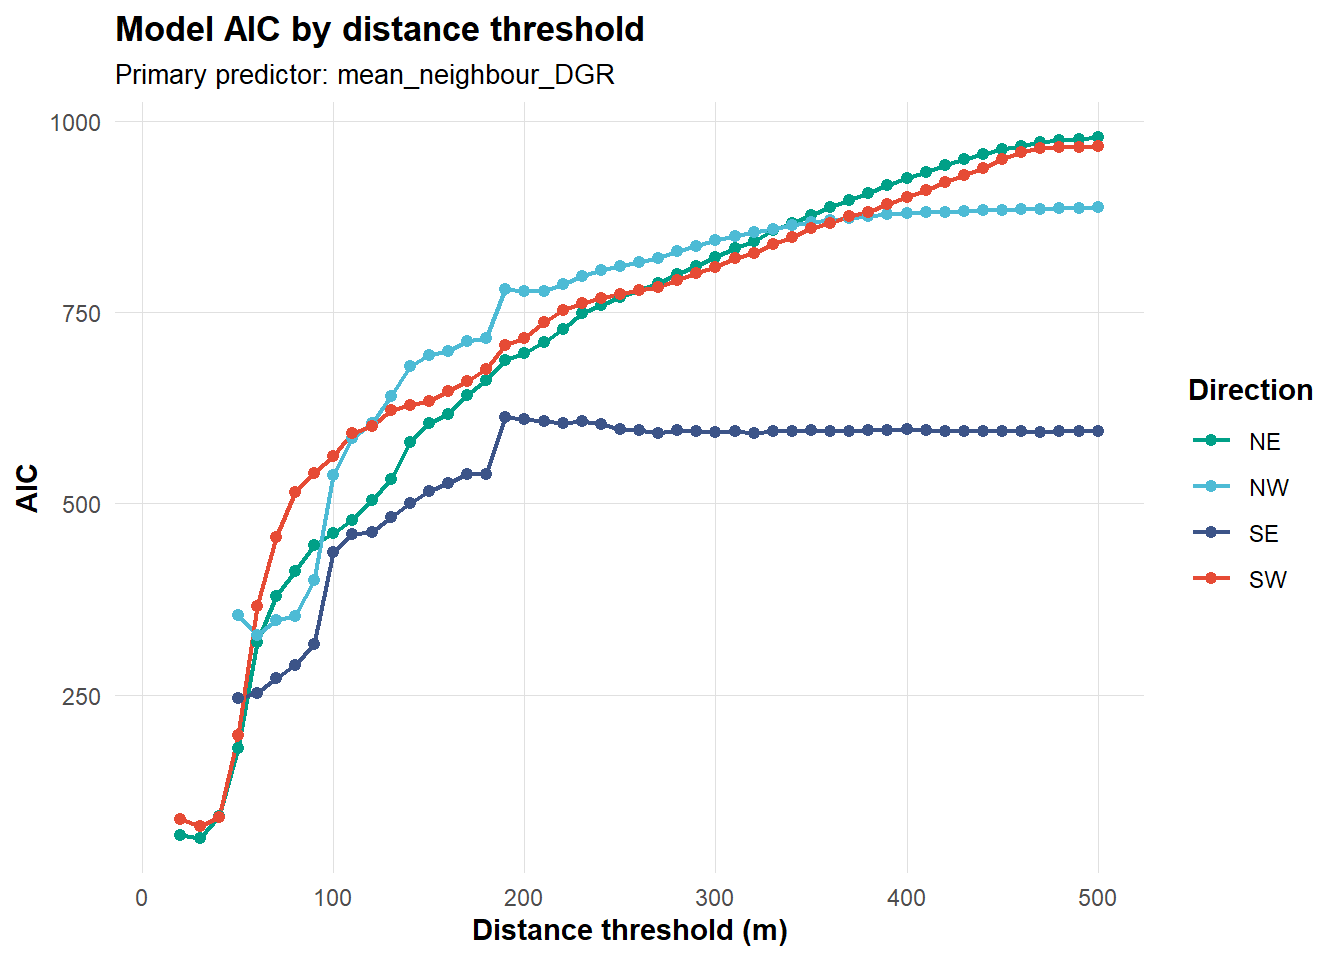

In [ ]:
r2_plot <- make_distance_plot(
  model_results = model_results,
  y_var = "r_squared",
  y_label = expression(R^2),
  file_path = file.path(output_dir, "r2_by_distance_direction.png")
) +
  labs(
    title = "Model R² by distance threshold",
    subtitle = paste("Primary predictor:", primary_predictor)
  )
save_plot(r2_plot, file.path(output_dir, "r2_by_distance_direction.png"))

slope_plot <- make_distance_plot(
  model_results = model_results,
  y_var = "slope",
  y_label = "Slope",
  file_path = file.path(output_dir, "slope_by_distance_direction.png")
) +
  labs(
    title = "Model slope by distance threshold",
    subtitle = paste("Primary predictor:", primary_predictor)
  )
save_plot(slope_plot, file.path(output_dir, "slope_by_distance_direction.png"))

pvalue_plot <- make_distance_plot(
  model_results = model_results,
  y_var = "p_value",
  y_label = "p-value",
  file_path = file.path(output_dir, "pvalue_by_distance_direction.png"),
  add_p_line = TRUE
) +
  labs(
    title = "Model p-value by distance threshold",
    subtitle = paste("Primary predictor:", primary_predictor)
  )
save_plot(pvalue_plot, file.path(output_dir, "pvalue_by_distance_direction.png"))

aic_plot <- make_distance_plot(
  model_results = model_results,
  y_var = "AIC",
  y_label = "AIC",
  file_path = file.path(output_dir, "aic_by_distance_direction.png")
) +
  labs(
    title = "Model AIC by distance threshold",
    subtitle = paste("Primary predictor:", primary_predictor)
  )
save_plot(aic_plot, file.path(output_dir, "aic_by_distance_direction.png"))

r2_plot

## Best Distance Threshold Summary

In [ ]:
primary_results <- model_results |>
  filter(predictor == primary_predictor)

best_r2_tbl <- primary_results |>
  filter(!is.na(r_squared)) |>
  group_by(direction) |>
  arrange(desc(r_squared), p_value, distance_threshold_m, .by_group = TRUE) |>
  slice(1) |>
  ungroup() |>
  transmute(
    direction = direction,
    best_r2_threshold_m = distance_threshold_m,
    best_r2 = r_squared,
    best_r2_slope = slope,
    best_r2_p_value = p_value,
    relationship_sign = relationship_sign
  )

best_aic_tbl <- primary_results |>
  filter(!is.na(AIC)) |>
  group_by(direction) |>
  arrange(AIC, distance_threshold_m, .by_group = TRUE) |>
  slice(1) |>
  ungroup() |>
  transmute(
    direction = direction,
    best_aic_threshold_m = distance_threshold_m,
    best_aic = AIC
  )

shortest_sig_tbl <- primary_results |>
  filter(!is.na(p_value), p_value < 0.05) |>
  group_by(direction) |>
  arrange(distance_threshold_m, .by_group = TRUE) |>
  slice(1) |>
  ungroup() |>
  transmute(
    direction = direction,
    shortest_significant_threshold_m = distance_threshold_m
  )

best_summary <- tibble(direction = direction_levels) |>
  left_join(best_r2_tbl, by = "direction") |>
  left_join(best_aic_tbl, by = "direction") |>
  left_join(shortest_sig_tbl, by = "direction") |>
  mutate(direction = as.character(direction))

utils::write.csv(
  best_summary,
  file.path(output_dir, "best_distance_threshold_summary.csv"),
  row.names = FALSE
)

best_summary

# A tibble: 4 × 9
  direction best_r2_threshold_m best_r2 best_r2_slope best_r2_p_value
  <chr>                   <dbl>   <dbl>         <dbl>           <dbl>
1 SW                         30   0.765         0.891       1.35e-174
2 NW                         60   0.586         0.944       2.66e- 97
3 NE                         30   0.763         0.856       1.10e-173
4 SE                         60   0.553         0.712       1.42e- 88
# ℹ 4 more variables: relationship_sign <chr>, best_aic_threshold_m <dbl>,
#   best_aic <dbl>, shortest_significant_threshold_m <dbl>

## Best Directional Relationships

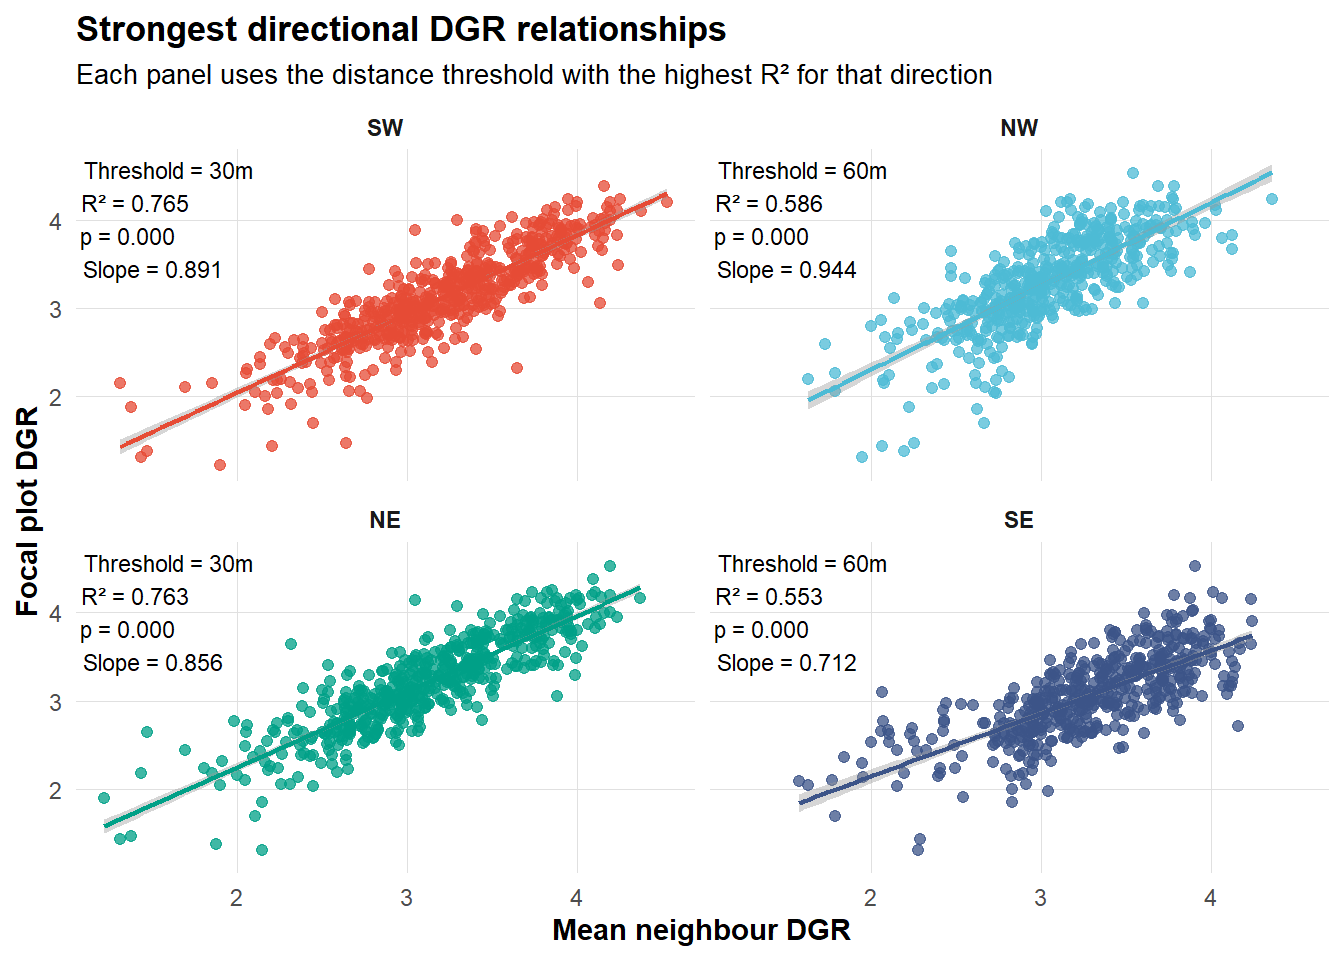

In [ ]:
best_scatter_tbl <- best_summary |>
  filter(!is.na(best_r2_threshold_m)) |>
  select(direction, selected_threshold_m = best_r2_threshold_m) |>
  inner_join(
    metrics_tbl,
    by = "direction"
  ) |>
  filter(distance_threshold_m == selected_threshold_m) |>
  mutate(direction = factor(direction, levels = direction_levels))

scatter_annotations <- best_summary |>
  mutate(
    direction = factor(direction, levels = direction_levels),
    annotation = ifelse(
      is.na(best_r2_threshold_m),
      "No valid model",
      sprintf(
        "Threshold = %dm\nR² = %.3f\np = %.3f\nSlope = %.3f",
        best_r2_threshold_m,
        best_r2,
        best_r2_p_value,
        best_r2_slope
      )
    )
  )

best_scatter_plot <- best_scatter_tbl |>
  ggplot(aes(x = mean_neighbour_DGR, y = DGR, colour = direction)) +
  geom_point(alpha = 0.75, size = 1.7, na.rm = TRUE) +
  geom_smooth(
    method = "lm",
    formula = y ~ x,
    se = TRUE,
    linewidth = 0.8,
    na.rm = TRUE
  ) +
  facet_wrap(~ direction, scales = "fixed", drop = FALSE) +
  geom_text(
    data = scatter_annotations,
    aes(
      x = -Inf,
      y = Inf,
      label = annotation
    ),
    inherit.aes = FALSE,
    hjust = -0.05,
    vjust = 1.1,
    size = 3.0,
    colour = "black"
  ) +
  scale_colour_manual(values = direction_palette, drop = FALSE) +
  labs(
    title = "Strongest directional DGR relationships",
    subtitle = "Each panel uses the distance threshold with the highest R² for that direction",
    x = "Mean neighbour DGR",
    y = "Focal plot DGR",
    colour = "Direction"
  ) +
  theme_spatial() +
  theme(legend.position = "none")

save_plot(
  best_scatter_plot,
  file.path(output_dir, "best_directional_relationships.png"),
  width = 10,
  height = 7.5
)

best_scatter_plot

## Spatial Autocorrelation

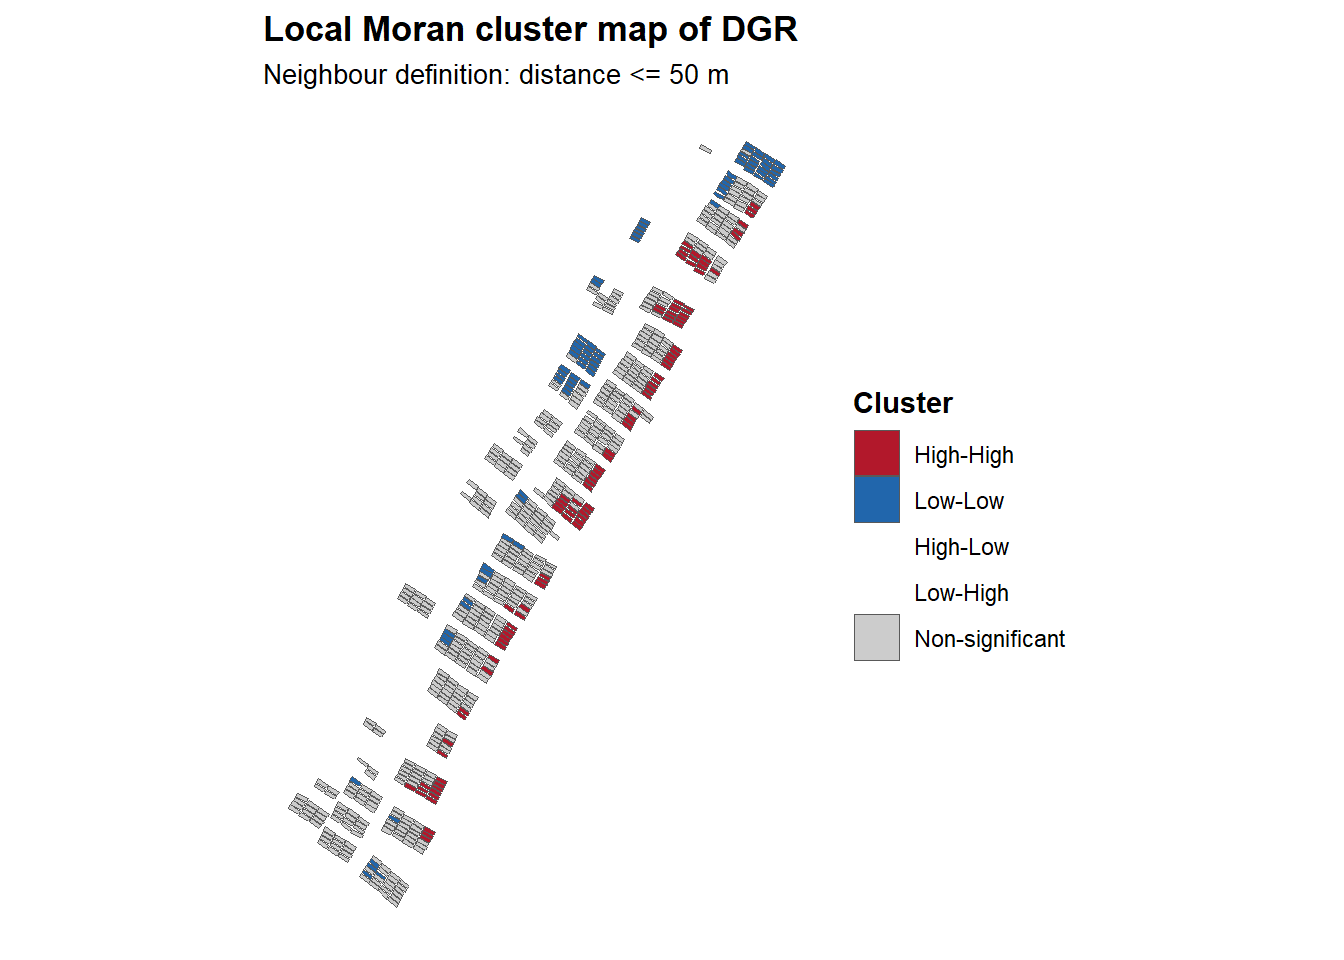

In [ ]:
coords_matrix <- as.matrix(st_drop_geometry(plot_sf)[, c("x", "y")])
dist_matrix <- as.matrix(stats::dist(coords_matrix))
dgr_values <- plot_sf$DGR

distance_moran_results <- purrr::map_dfr(moran_distance_thresholds, function(threshold_m) {
  weights_obj <- build_distance_weights(dist_matrix, threshold_m)
  compute_global_moran(
    values = dgr_values,
    neighbours = weights_obj$neighbours,
    weights = weights_obj$weights,
    n_perm = global_moran_permutations
  ) |>
    mutate(
      method = "distance",
      distance_threshold_m = threshold_m
    )
})

adjacency_weights <- build_adjacency_weights(plot_sf)
adjacency_moran_results <- compute_global_moran(
  values = dgr_values,
  neighbours = adjacency_weights$neighbours,
  weights = adjacency_weights$weights,
  n_perm = global_moran_permutations
) |>
  mutate(
    method = "adjacency",
    distance_threshold_m = NA_real_
  )

moran_global_results <- bind_rows(distance_moran_results, adjacency_moran_results) |>
  select(
    method,
    distance_threshold_m,
    moran_i,
    expected_i,
    p_value,
    n_permutations,
    mean_neighbours,
    min_neighbours,
    max_neighbours,
    n_isolates
  )

utils::write.csv(
  moran_global_results,
  file.path(output_dir, "moran_global_results.csv"),
  row.names = FALSE
)

local_moran_definition <- select_local_moran_definition(moran_global_results)

local_weights <- if (local_moran_definition$method[1] == "distance") {
  build_distance_weights(dist_matrix, local_moran_definition$distance_threshold_m[1])
} else {
  adjacency_weights
}

local_moran_tbl <- compute_local_moran(
  values = dgr_values,
  neighbours = local_weights$neighbours,
  weights = local_weights$weights,
  n_perm = local_moran_permutations,
  alpha = local_moran_alpha
)

local_moran_sf <- bind_cols(plot_sf, local_moran_tbl)

local_moran_map <- ggplot(local_moran_sf) +
  geom_sf(aes(fill = cluster), colour = "grey35", linewidth = 0.08) +
  scale_fill_manual(values = local_moran_palette, drop = FALSE) +
  labs(
    title = "Local Moran cluster map of DGR",
    subtitle = if (local_moran_definition$method[1] == "distance") {
      paste0(
        "Neighbour definition: distance <= ",
        local_moran_definition$distance_threshold_m[1],
        " m"
      )
    } else {
      "Neighbour definition: polygon adjacency"
    },
    x = NULL,
    y = NULL,
    fill = "Cluster"
  ) +
  coord_sf(datum = NA) +
  theme_spatial()

save_plot(
  local_moran_map,
  file.path(output_dir, "local_moran_map.png"),
  width = 8.5,
  height = 6.5
)

local_moran_cluster_counts <- local_moran_sf |>
  st_drop_geometry() |>
  count(cluster, name = "n")

local_moran_map

## Empirical Variogram

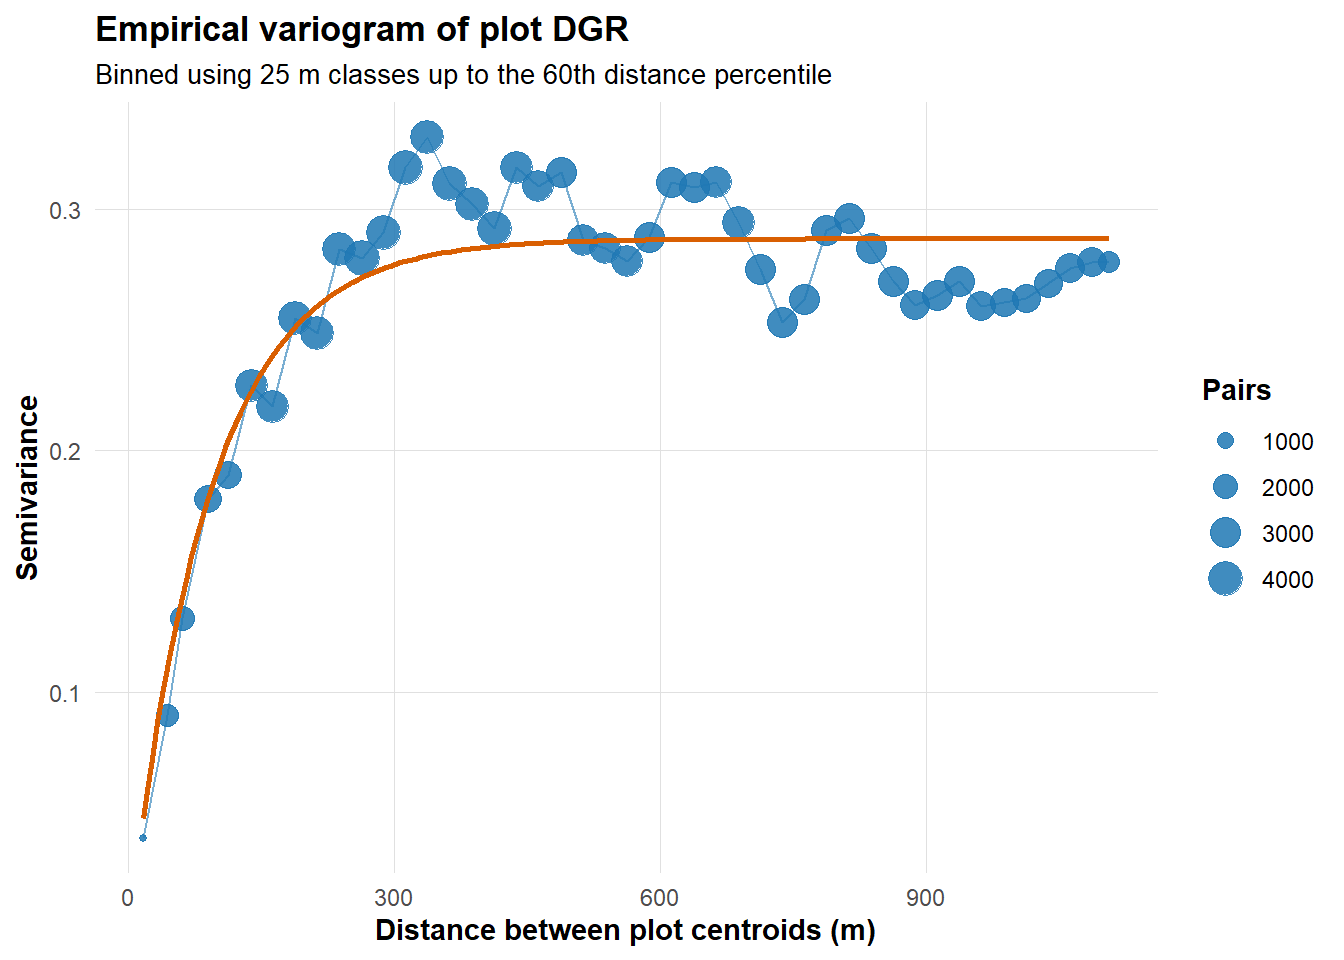

In [ ]:
variogram_objects <- build_empirical_variogram(
  pairwise_all = pairwise_all,
  max_distance_quantile = variogram_max_distance_quantile,
  bin_width_m = variogram_bin_width_m
)

empirical_variogram_tbl <- variogram_objects$empirical
variogram_fit <- fit_simple_variogram_model(empirical_variogram_tbl)

variogram_plot <- ggplot(empirical_variogram_tbl, aes(x = mean_distance_m, y = gamma)) +
  geom_point(aes(size = n_pairs), colour = "#1F78B4", alpha = 0.85) +
  geom_line(colour = "#1F78B4", linewidth = 0.5, alpha = 0.6) +
  labs(
    title = "Empirical variogram of plot DGR",
    subtitle = sprintf(
      "Binned using %.0f m classes up to the %.0fth distance percentile",
      variogram_bin_width_m,
      variogram_max_distance_quantile * 100
    ),
    x = "Distance between plot centroids (m)",
    y = "Semivariance",
    size = "Pairs"
  ) +
  theme_spatial()

if (!is.null(variogram_fit)) {
  variogram_curve <- data.frame(
    mean_distance_m = seq(
      min(empirical_variogram_tbl$mean_distance_m),
      max(empirical_variogram_tbl$mean_distance_m),
      length.out = 200
    )
  )
  variogram_curve$gamma <- stats::predict(variogram_fit, newdata = variogram_curve)

  variogram_plot <- variogram_plot +
    geom_line(
      data = variogram_curve,
      aes(x = mean_distance_m, y = gamma),
      inherit.aes = FALSE,
      colour = "#D95F02",
      linewidth = 0.9
    )
}

save_plot(
  variogram_plot,
  file.path(output_dir, "dgr_variogram.png"),
  width = 8.5,
  height = 6.0
)

variogram_plot

## Summary Figure

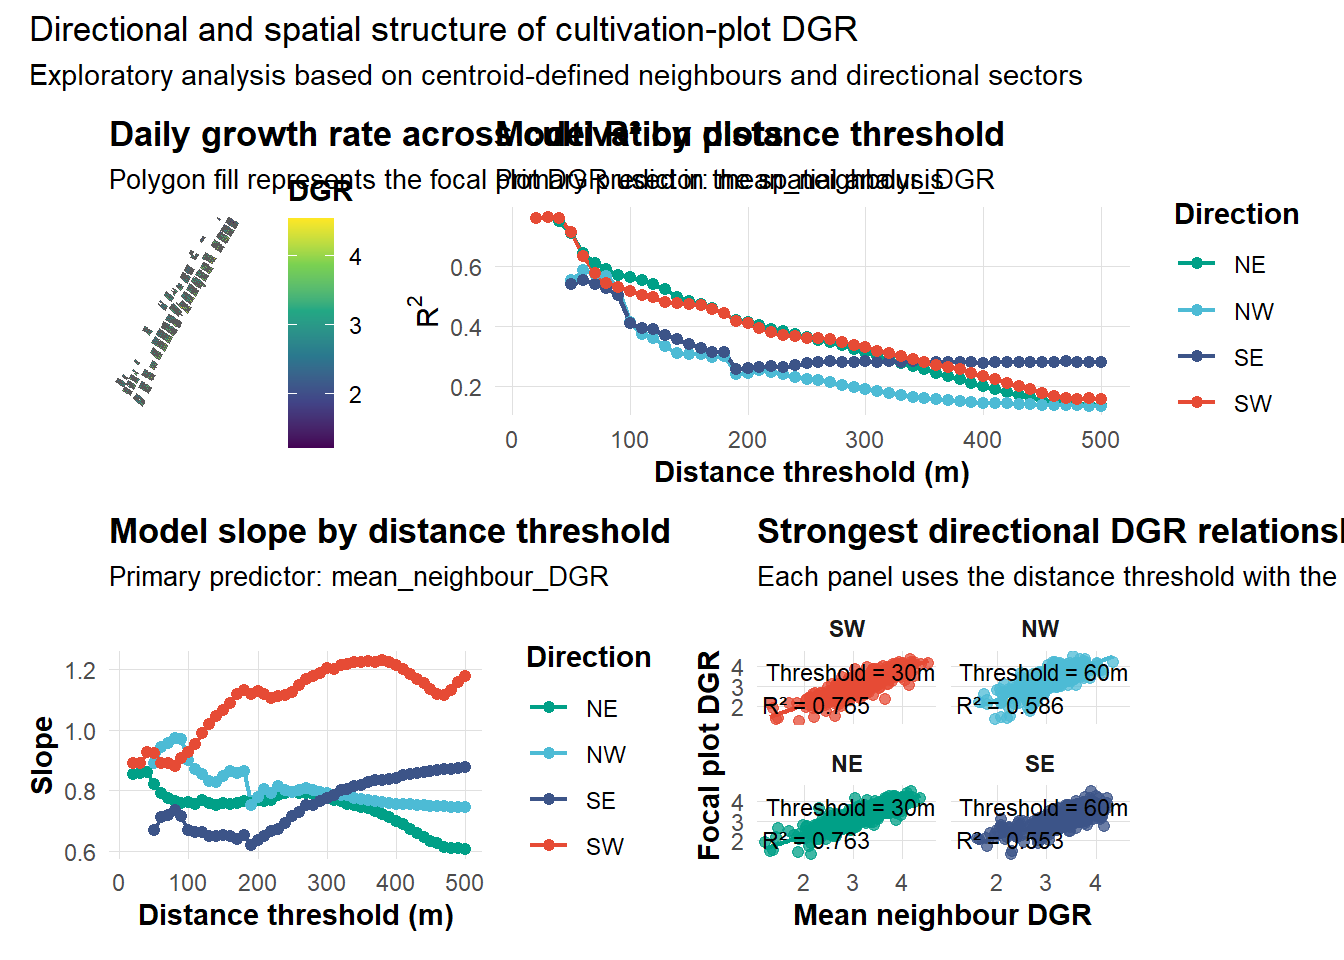

In [ ]:
summary_figure <- (dgr_map | r2_plot) / (slope_plot | best_scatter_plot) +
  plot_annotation(
    title = "Directional and spatial structure of cultivation-plot DGR",
    subtitle = "Exploratory analysis based on centroid-defined neighbours and directional sectors"
  )

save_plot(
  summary_figure,
  file.path(output_dir, "spatial_analysis_summary_figure.png"),
  width = 14,
  height = 10
)

summary_figure

## Automated Interpretation File

In [ ]:
strongest_direction_row <- best_summary |>
  filter(!is.na(best_r2)) |>
  arrange(desc(best_r2), best_r2_p_value, best_r2_threshold_m) |>
  slice_head(n = 1)

write_interpretation(
  output_file = file.path(output_dir, "spatial_analysis_interpretation.md"),
  metadata = metadata,
  best_summary = best_summary,
  moran_results = moran_global_results,
  local_cluster_counts = local_moran_cluster_counts,
  strongest_direction_row = strongest_direction_row,
  local_moran_definition = local_moran_definition,
  variogram_fit = variogram_fit
)

## Console Summary

In [ ]:
cat("\nSpatial analysis complete.\n")


Spatial analysis complete.

Outputs saved to: C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis 

Strongest directional relationship: SW at 30 m using mean_neighbour_DGR (R² = 0.765, slope = 0.891, p = 0.000).